# Look and check the bunch trains around the EUXFEL switchyard

In [62]:
import os
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis/')

import numpy as _np
import matplotlib.pyplot as _plt
import matplotlib.ticker as mtick
import matplotlib.patches as _patch
from pdf2image import convert_from_path

import XFEL_BPM
import loadXFELdata

### Date and save prefix

In [10]:
date = "2026_06_02"
save_name_prefix = "jupyter_notebooks/plots/XFEL/" + date + "_EuXFEL_plot"

In [148]:
def checkTrainBunchConsistancy(df):
    # df = getH5dataInDF(inputfilename, getPosition=False)
    df_valid = reduceDFbyBPMTrainBunchByIndex(df)
    bpmids_count = df_valid.index.get_level_values(0).value_counts(sort=False).values
    nbpm = len(bpmids_count)
    # print('nbbpms = ', nbpm)
    trainids_count = df_valid.index.get_level_values(1).value_counts(sort=False).values
    ntrains = len(trainids_count)
    # print('nbtrains = ', ntrains)
    bunchids_count = df_valid.index.get_level_values(2).value_counts(sort=False).values
    nbunches = len(bunchids_count)
    # print('nbbunches = ', nbunches)

    A = bpmids_count/ntrains
    B = trainids_count
    C = bunchids_count/ntrains

    fig, ax = plotOptions(figsize=[14, 8], rows_colums=[3, 1])
    _plt.subplot(3, 1, 1)
    _plt.plot(_np.abs(A - A.round()))
    bpmnames = df_valid.index.get_level_values(0).unique().values
    ax[0].set_xticks(range(len(bpmnames)))
    ax[0].set_xticklabels(bpmnames, fontsize=8, rotation=45, ha='right')
    _plt.subplot(3, 1, 2)
    _plt.plot(B)
    ax[1].ticklabel_format(useOffset=False)
    _plt.subplot(3, 1, 3)
    _plt.plot(_np.abs(C - C.round()))

In [3]:
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file114155_20231120T155943.all.hdf5'
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file109482_20231119T155947.all.hdf5'
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file118300_20231121T155956.all.hdf5'
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file122942_20231122T155946.all.hdf5'
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file128226_20231123T155954.all.hdf5'

In [16]:
BPMData = loadXFELdata.XFELdata('XFEL_data/BPM_data/matched_linac_main_run2148_file128226_20231123T155954.all.hdf5', 
                                getPosition=True, getCharge=False, getEnergy=False, getTime=False)

Loaded file 'matched_linac_main_run2148_file128226_20231123T155954.all.hdf5'
Loading 49 bpms, 3180 trains and 2708 bunches in df: |██████████████████████████████████████████████████| 100.0% Complete


In [6]:
df_valid = BPMData.df_bpm[BPMData.df_bpm.Valid==1]
# df_valid = df_valid[~df_valid.index.get_level_values('BPM').isin(BPMData.bpmIDs_TLD)]

In [7]:
df_bpm_t1 = df_valid.xs('BPMA.2097.T1', level='BPM')
bunchIDs_T1 = df_bpm_t1.index.get_level_values('BunchID').unique().values
df_T1 = df_valid[df_valid.index.get_level_values('BunchID').isin(bunchIDs_T1)]

In [8]:
df_bpm_t2 = df_valid.xs('BPMA.2071.T2', level='BPM')
bunchIDs_T2 = df_bpm_t2.index.get_level_values('BunchID').unique().values
df_T2 = df_valid[df_valid.index.get_level_values('BunchID').isin(bunchIDs_T2)]

In [21]:
inconsistant_trains_T1 = []
inconsistant_trains_T2 = []
len_T1 = len(bunchIDs_T1)*(len(BPMData.bpmIDs_T1) + len(BPMData.bpmIDs_TL))
len_T2 = len(bunchIDs_T2)*(len(BPMData.bpmIDs_T2) + len(BPMData.bpmIDs_TL))
for i, trainID in enumerate(BPMData.trainIDs_matched):
    print("{}/{}".format(i+1, BPMData.nbtrain), end='\r')
    df_T1_train = df_T1.xs(trainID, level='TrainID')
    df_T2_train = df_T2.xs(trainID, level='TrainID')
    if len(df_train) != len_T1: inconsistant_trains_T1.append(trainID)
    if len(df_train) != len_T2: inconsistant_trains_T2.append(trainID)

In [29]:
len(inconsistant_trains_T1)

3180

In [22]:
df_T2_filtered = df_T2[~df_T2.index.get_level_values('TrainID').isin(L)]

In [23]:
non_TLD_bunchIDs = _np.append(df_T2.index.get_level_values('BunchID').unique(), df_T1.index.get_level_values('BunchID').unique())

In [24]:
df_TL = df_valid[~df_valid.index.get_level_values('BunchID').isin(non_TLD_bunchIDs)]

In [25]:
bpmids_count = df_T2.index.get_level_values('BPM').value_counts(sort=False).values
nbpm = len(bpmids_count)
trainids_count = df_T2.index.get_level_values('TrainID').value_counts(sort=False).values
ntrains = len(trainids_count)
bunchids_count = df_T2.index.get_level_values('BunchID').value_counts(sort=False).values
nbunches = len(bunchids_count)

In [26]:
print(_np.unique(bpmids_count))
print(_np.unique(trainids_count))
print(_np.unique(bunchids_count))

[2078130 2308680]
[ 8731 22506]
[92538 98580]


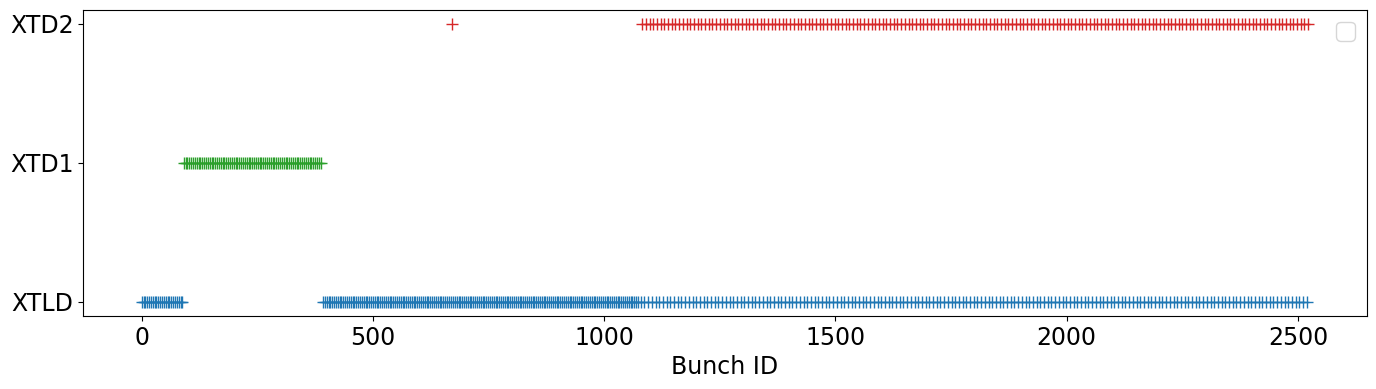

In [11]:
BPMData.plotBunchPattern(train=0, sample=4)
_plt.savefig("{}_Bunch_patern.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

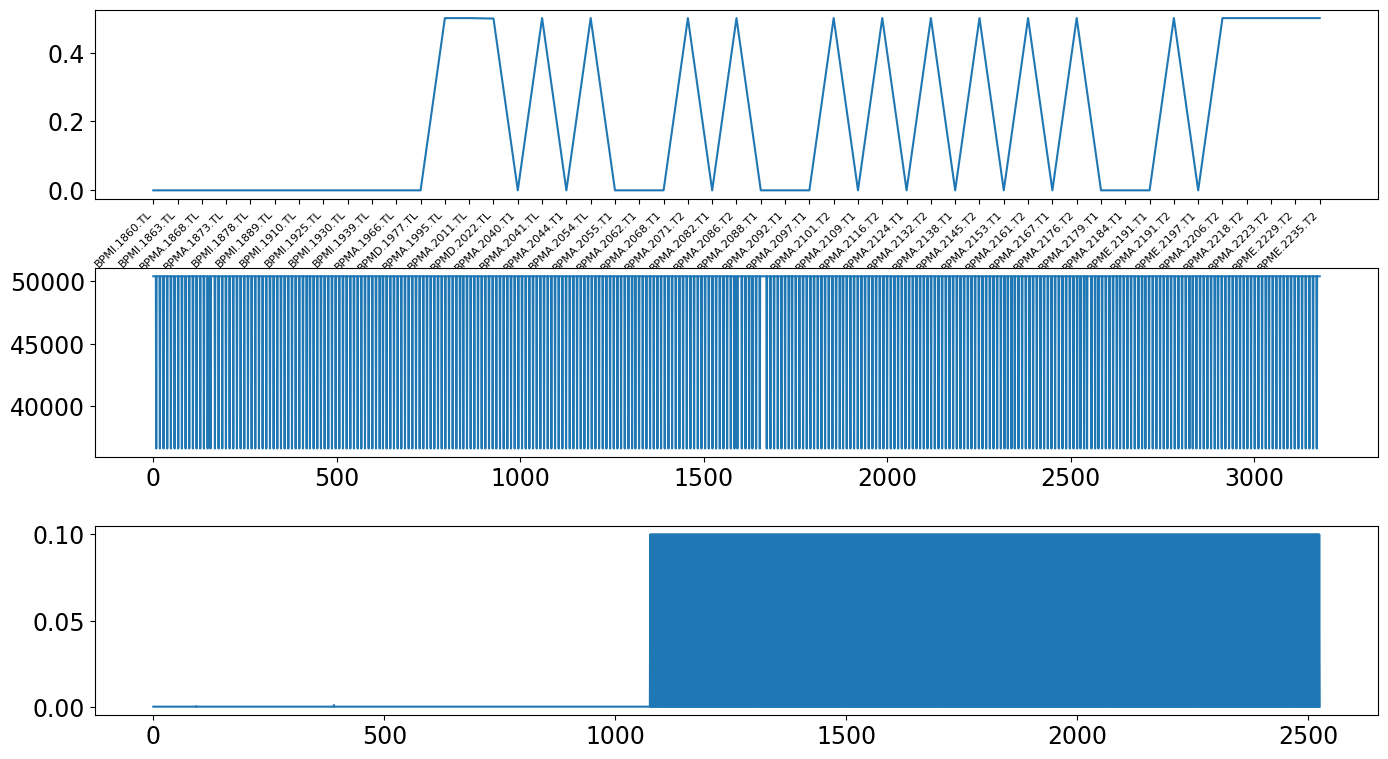

In [47]:
XFEL_BPM.checkTrainBunchConsistancy(df_bp)